In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation


import scipy
import numpy as np
import pandas as pd
import datetime as dt

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

In [84]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout.clustering as clstr
import bout.assembly as bt

In [85]:
from models.bat_call_detector.model_detector import BatCallDetector

In [86]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

In [244]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 600
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 46.5625
ZMAG_REF_TO_1 = 35.5
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [0, 0, -ZMAG_REF_TO_1],
                    [0, 0, 0]])

In [245]:
import UBNA_localize_process_GCC__20250427 as localize

In [246]:
%matplotlib inline

microphones_used = np.array([1, 2, 3, 4, 5, 6, 7, 8])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

file_dir = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array')
site_key = 'Carp'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = dict()
file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
bout_params = bt.get_bout_params_from_location(location_df, data_params)
bout_params

{'site_key': 'Carp', 'LF_bci': 3904.554260760447, 'HF_bci': 5203.014061749601}

In [247]:
%matplotlib inline
FILE_DATETIME = dt.datetime(2025,4,24,8,30)
file_offset = 600
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']
removed_overlaps = localize.remove_overlapping_events(channel_dets, OVERLAP_TIME_THRESHOLD=12e-3)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()

In [248]:
tagged_dets = bt.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
bout_metrics

,start_time_of_bout,end_time_of_bout,start_time_wrt_ref,end_time_wrt_ref,start_time,end_time,low_freq,high_freq,freq_group,cycle_ref_time_start,cycle_ref_time_end,number_of_dets,bout_duration,bout_duration_in_secs
0,2025-04-24 08:41:19.888500000,2025-04-24 08:41:28.324000000,679.8885,688.3240,679.8885,688.3240,24609,42211,LF,2025-04-24 08:41:19.888500000,2025-04-24 08:41:28.309500000,35,0 days 00:00:08.435500,8.435500
1,2025-04-24 08:42:08.546500000,2025-04-24 08:42:14.806400000,728.5465,734.8064,728.5465,734.8064,22031,50716,LF,2025-04-24 08:42:08.546500000,2025-04-24 08:42:14.790500000,27,0 days 00:00:06.259900,6.259900
2,2025-04-24 08:42:37.509500000,2025-04-24 08:42:39.239300000,757.5095,759.2393,757.5095,759.2393,25468,31835,LF,2025-04-24 08:42:37.509500000,2025-04-24 08:42:39.224500000,7,0 days 00:00:01.729800,1.729800
3,2025-04-24 08:42:44.016500000,2025-04-24 08:42:49.491900000,764.0165,769.4919,764.0165,769.4919,24609,44060,LF,2025-04-24 08:42:44.016500000,2025-04-24 08:42:49.477500000,8,0 days 00:00:05.475400,5.475400
4,2025-04-24 08:43:05.716500000,2025-04-24 08:43:42.100900000,785.7165,822.1009,785.7165,822.1009,21171,49900,LF,2025-04-24 08:43:05.716500000,2025-04-24 08:43:42.079500000,155,0 days 00:00:36.384400,36.384400
5,2025-04-24 08:43:49.466500000,2025-04-24 08:44:34.195700000,829.4665,874.1957,829.4665,874.1957,21171,47867,LF,2025-04-24 08:43:49.466500000,2025-04-24 08:44:34.182500000,131,0 days 00:00:44.729200,44.729200
6,2025-04-24 08:44:43.238499999,2025-04-24 08:44:54.078500000,883.2385,894.0785,883.2385,894.0785,21171,48255,LF,2025-04-24 08:44:43.238499999,2025-04-24 08:44:54.061500000,60,0 days 00:00:10.840000001,10.840000
7,2025-04-24 08:44:58.061500000,2025-04-24 08:46:04.468800000,898.0615,964.4688,898.0615,964.4688,21171,49816,LF,2025-04-24 08:44:58.061500000,2025-04-24 08:46:04.449500000,259,0 days 00:01:06.407300,66.407300
8,2025-04-24 08:46:08.984500000,2025-04-24 08:46:19.150200000,968.9845,979.1502,968.9845,979.1502,22031,50024,LF,2025-04-24 08:46:08.984500000,2025-04-24 08:46:19.130500000,45,0 days 00:00:10.165700,10.165700
9,2025-04-24 08:46:25.758500000,2025-04-24 08:46:46.807800000,985.7585,1006.8078,985.7585,1006.8078,22890,50542,LF,2025-04-24 08:46:25.758500000,2025-04-24 08:46:46.796499999,103,0 days 00:00:21.049300,21.049300


Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array/hour_0_600to1200/hour_0_channel7_600to1200.WAV


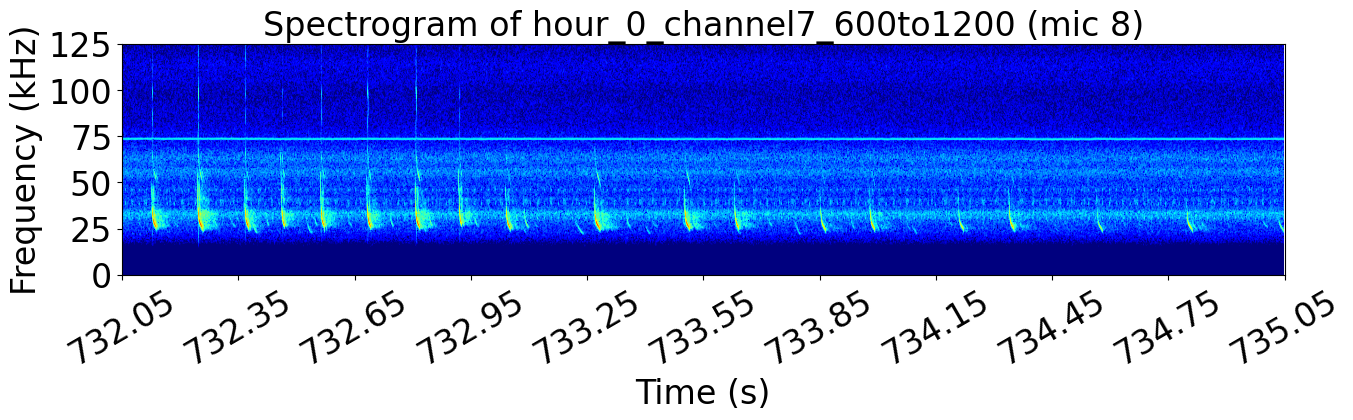

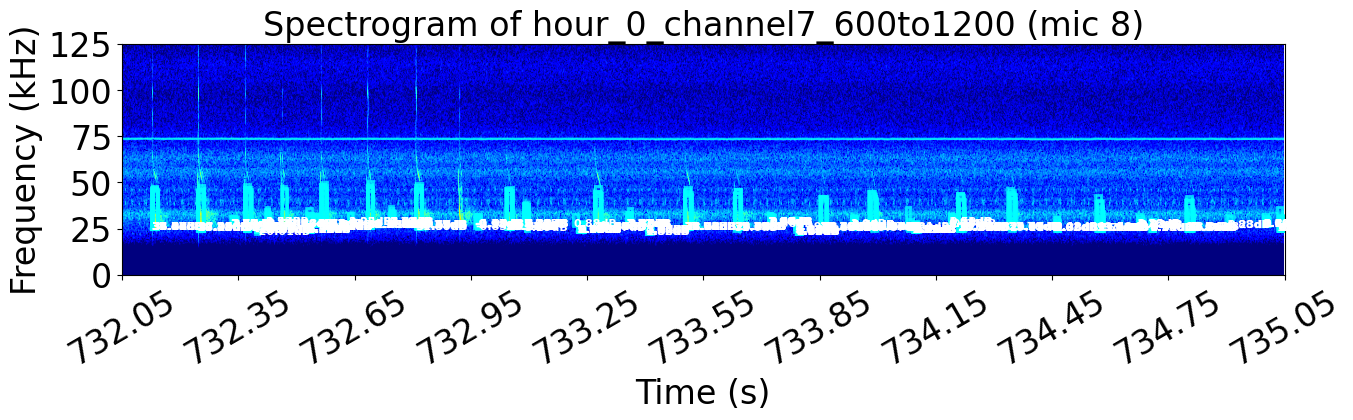

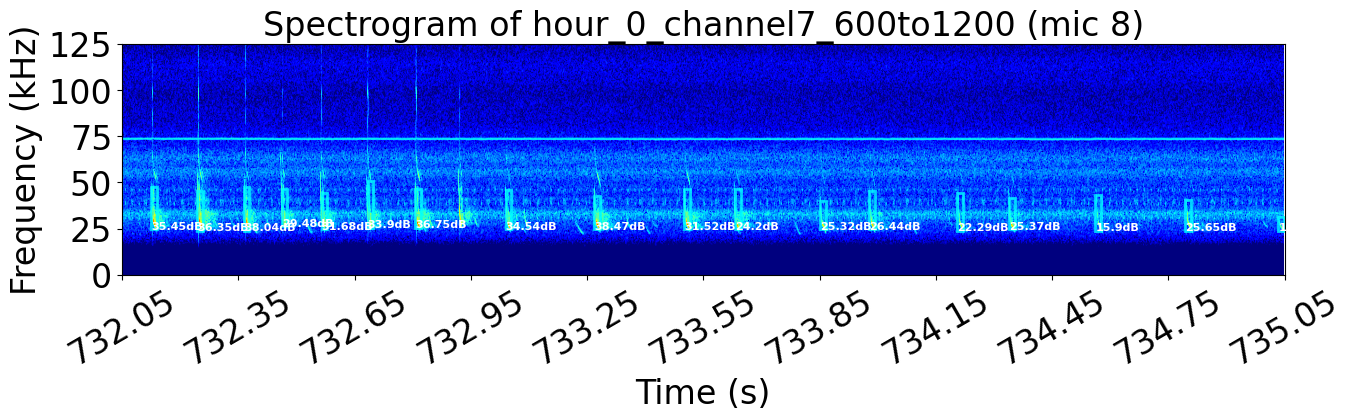

In [249]:
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[1]
start = bout['start_time'] - file_offset + 3.5
length = 3
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=10].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array/hour_0_600to1200/hour_0_channel7_600to1200.WAV


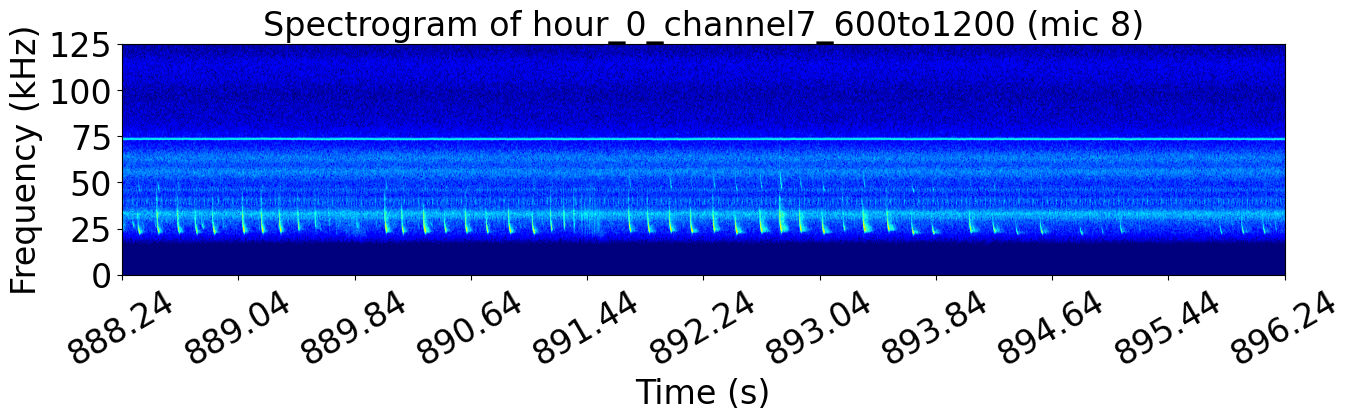

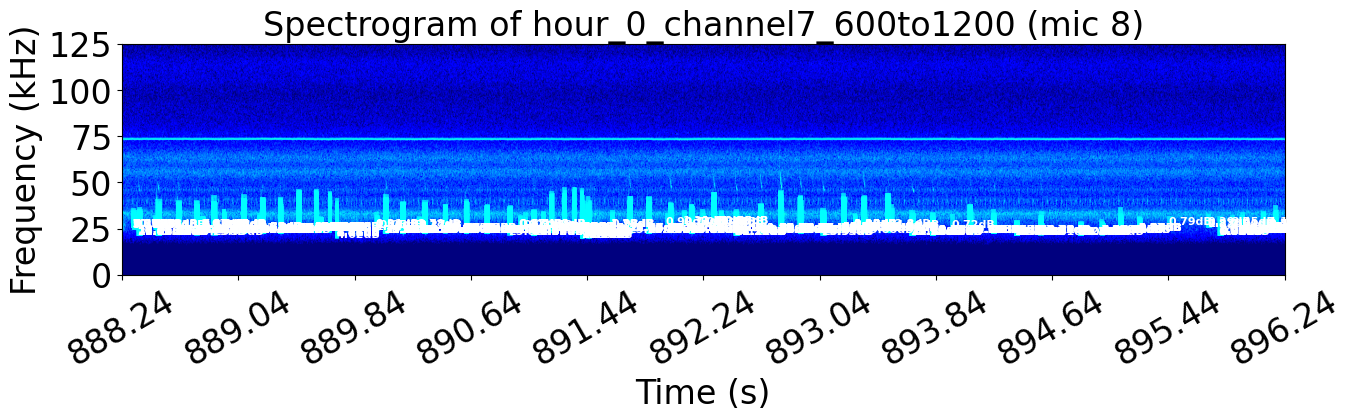

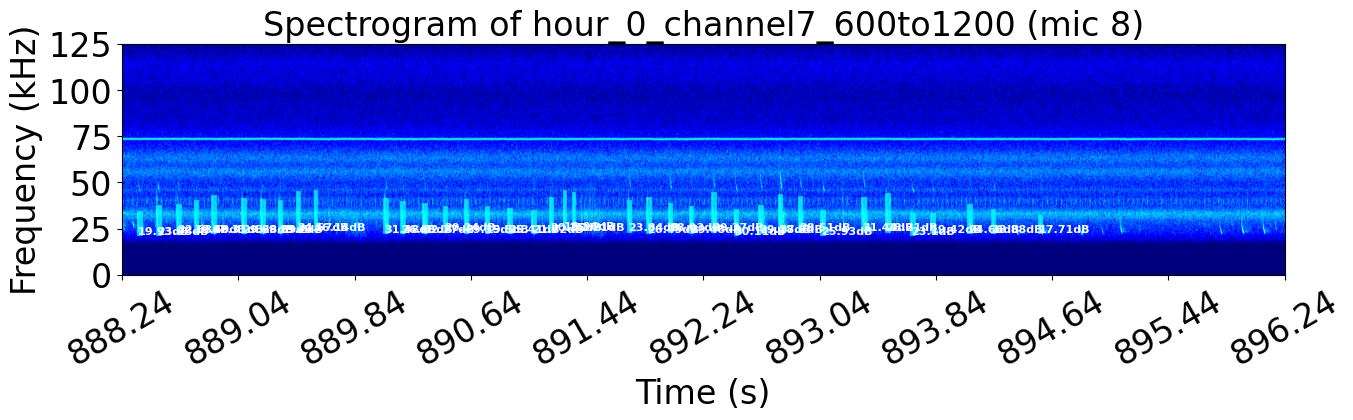

In [256]:
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[6]
start = bout['start_time'] - file_offset + 5
length = 8
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=15].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

In [257]:
calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

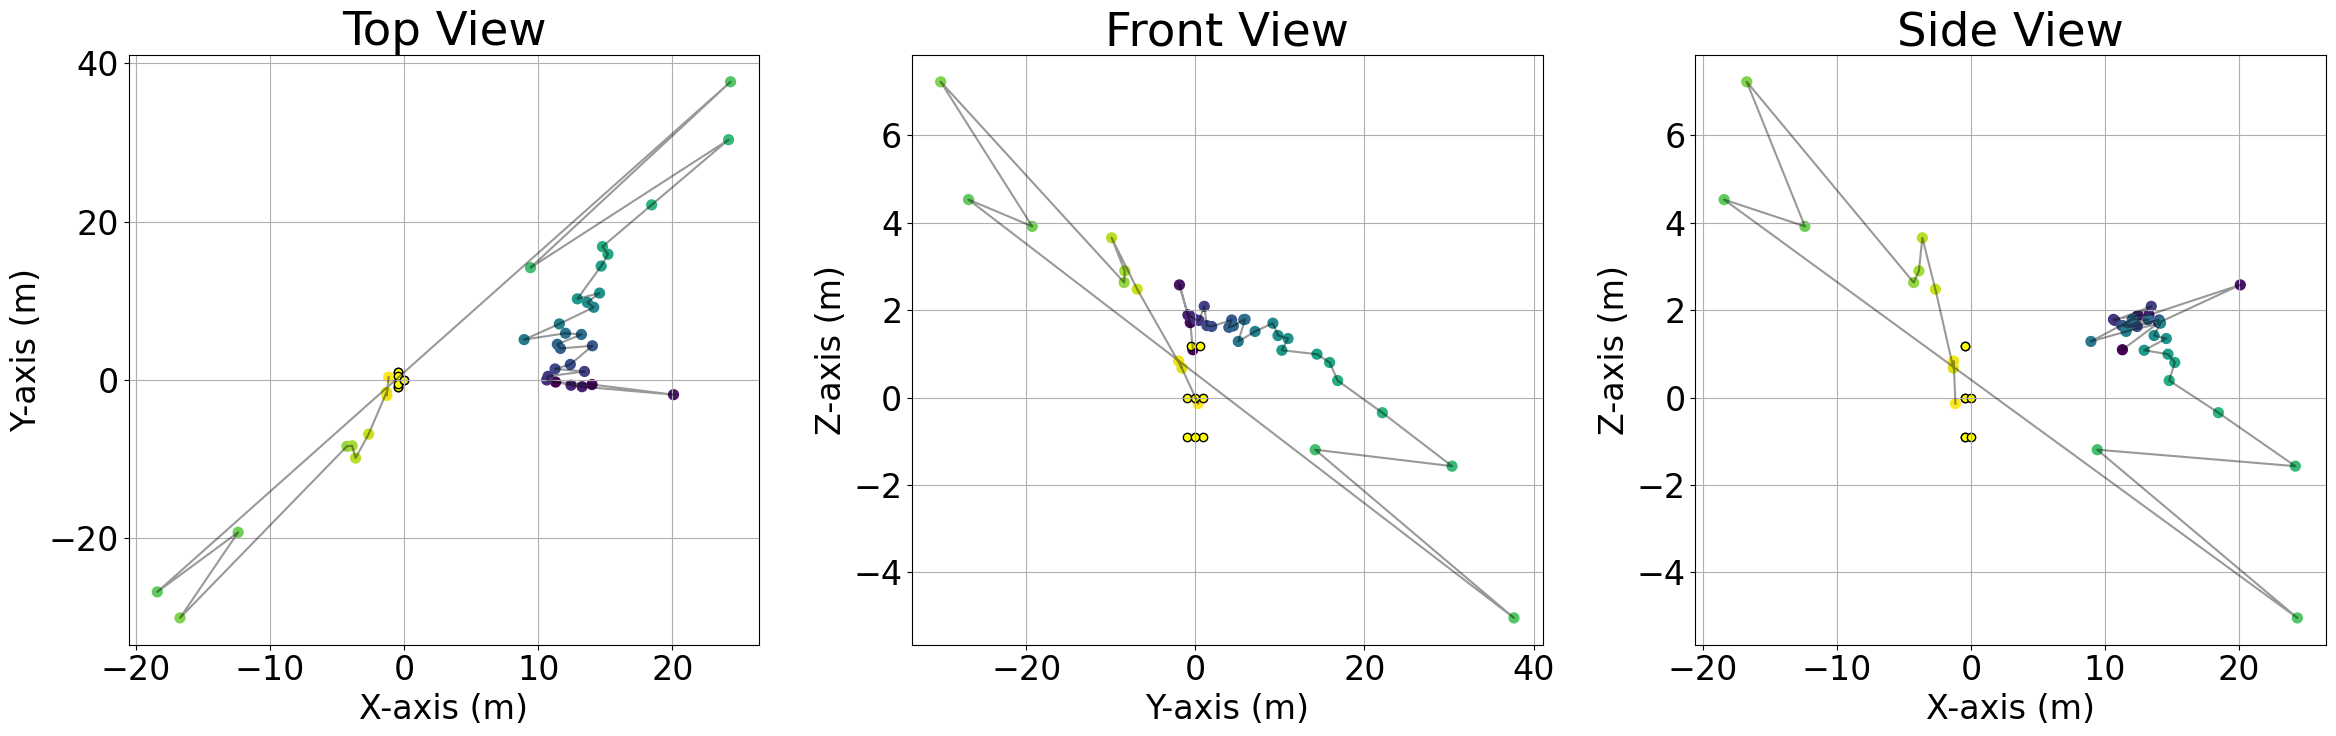

In [258]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, set_for_tdoa, source_points, source_points, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

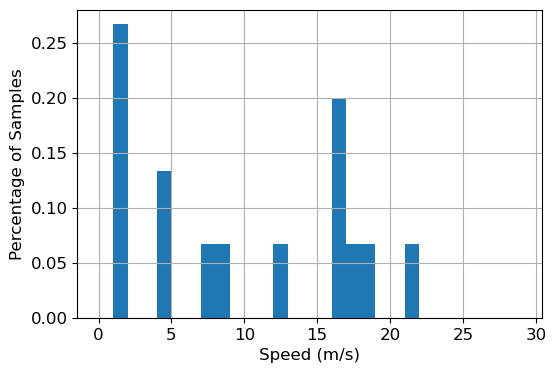

In [259]:
dist_travel_per_point = ((source_points[:,1:] - source_points[:,:-1])**2)[:3,:].sum(axis=0)
time_between_points = (set_for_tdoa['end_time'][1:].values - set_for_tdoa['start_time'][:-1].values)
speed_between_points = dist_travel_per_point / time_between_points

plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
plt.hist(speed_between_points, bins=np.arange(0,30,1), density=True)
plt.ylabel('Percentage of Samples')
plt.xlabel('Speed (m/s)')
plt.grid(which='both')
plt.show()

In [270]:
e1 = -0.6
e2 = 0
a = 1.5
b = 1

speed_threshold = 100
dets_with_valid_speeds = set_for_tdoa[np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
src_points_with_valid_speeds = source_points[:,np.concatenate([[speed_threshold], speed_between_points])<speed_threshold]
source_x_coords = src_points_with_valid_speeds[0,:]
source_y_coords = src_points_with_valid_speeds[1,:]
distance_of_points_from_ellipse = (((source_x_coords - e1) / a)**2) + (((source_y_coords - e2) / b)**2)

valid_dets_outside_unit_circle = dets_with_valid_speeds[distance_of_points_from_ellipse>1]
valid_speed_src_points_outside_unit_circle = src_points_with_valid_speeds[:,distance_of_points_from_ellipse>1]

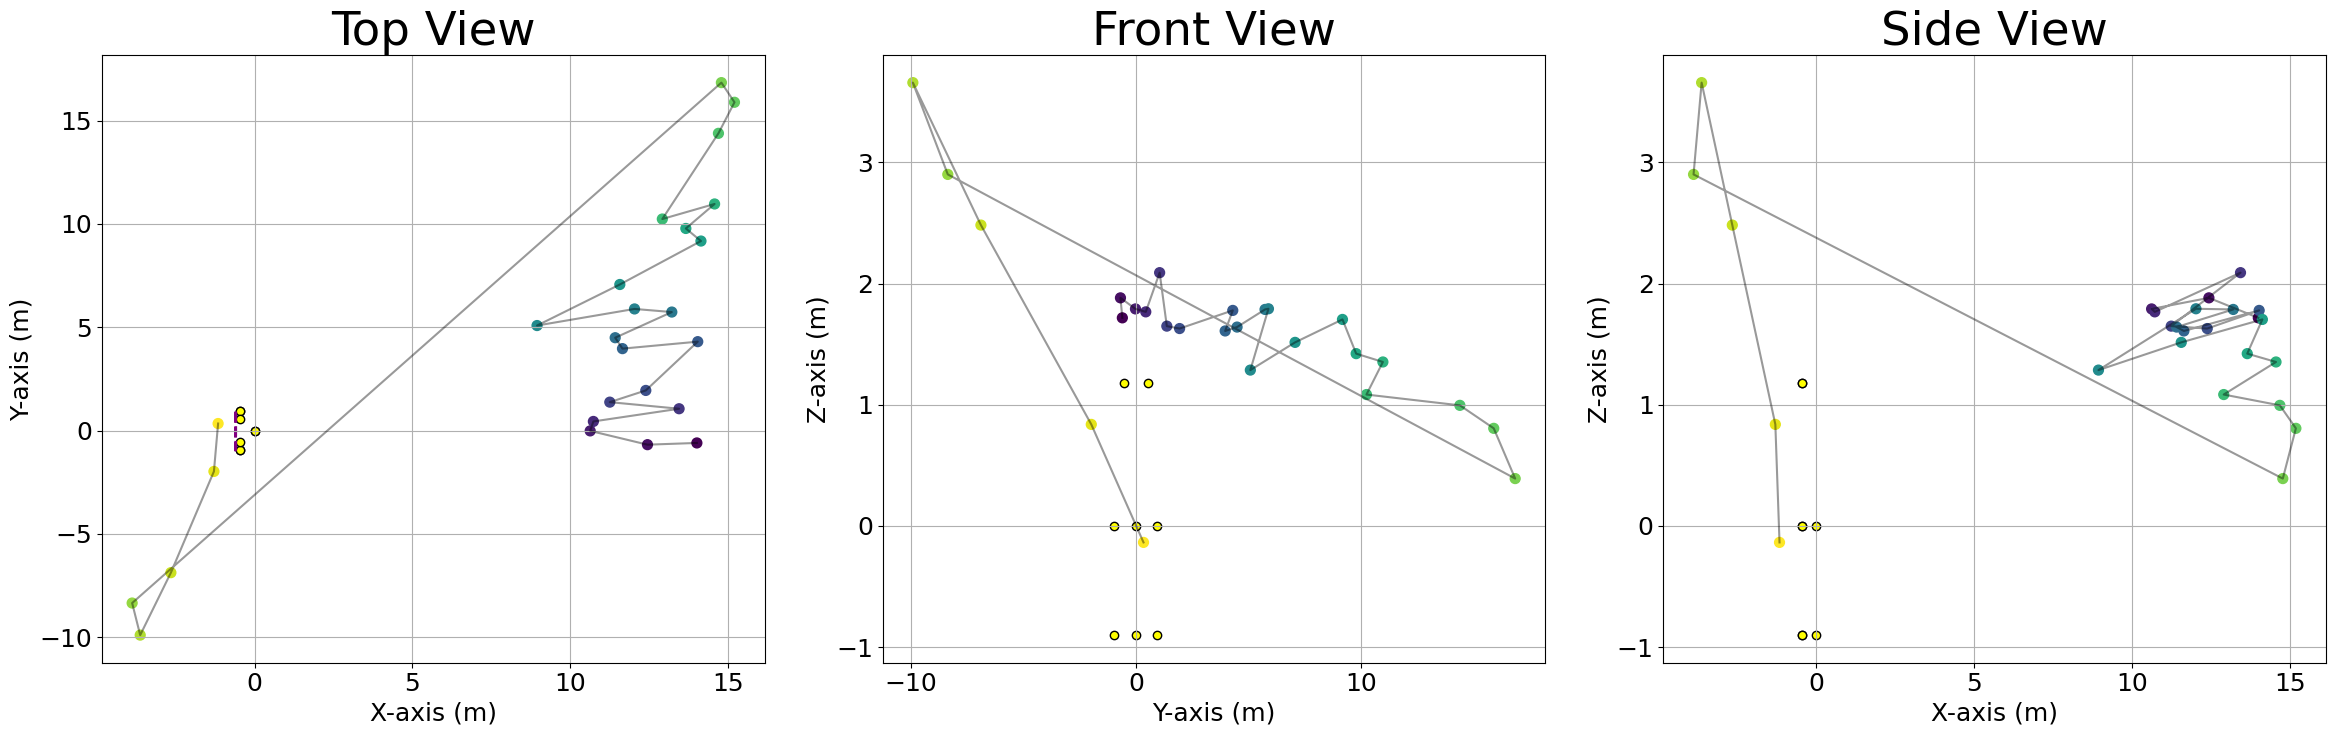

In [283]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, dets_with_valid_speeds, src_points_with_valid_speeds, 
                                       src_points_with_valid_speeds, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
ellipse = patches.Ellipse((e1, e2), width=2*a, height=2*b, edgecolor="purple", facecolor="none", linestyle="--", linewidth=2)
ax1.add_patch(ellipse)

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()

In [284]:
def plot_dB_labels_2d(ax, x_axis, y_axis, map_vals):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        ax.text(x=t_x, y=t_y, s=f'{round(map_vals[i], 1)}dB', fontsize=14)

def convertVtoRL(observed_voltage_rms, sens_dB, mic_gain_dB_at_f, preamp_gain):
    preamp_gain_dB = 20*np.log10(preamp_gain)
    receive_voltage_dB = 20*np.log10(observed_voltage_rms) -  preamp_gain_dB
    RL_dB_with_mic_sensitivity = receive_voltage_dB - mic_gain_dB_at_f
    RL_dB_re_20uPa = RL_dB_with_mic_sensitivity - sens_dB - 20*np.log10(20e-6)

    return RL_dB_re_20uPa

def absorption(f, t=20, rh=60):
    """ In dB/m
    
        f: frequency in Hz
        t: temperature in °C
        rh: relative humidity in %
        ps: atmospheric pressure in Pa

        From http://en.wikibooks.org/wiki/Engineering_Acoustics/Outdoor_Sound_Propagation
        See __main__ for actual curves.
    """
    ## 1 atm in Pa
    ps0 = 1.01325e5
    ps = ps0

    if type(f) != int:
        f = f.reshape(1, len(f))
    if type(t) != int:
        t = t.reshape(len(t), 1)
    if type(rh) != int:
        rh = rh.reshape(len(rh), 1)
    T = t + 273.15
    T0 = 293.15
    T01 = 273.16

    Csat = -6.8346 * np.power(T01 / T, 1.261) + 4.6151
    rhosat = np.power(10, Csat)
    H = rhosat * rh * ps0 / ps

    frn = (ps / ps0) * np.power(T0 / T, 0.5) * (
            9 + 280 * H * np.exp(-4.17 * (np.power(T0 / T, 1/3.) - 1)))

    fro = (ps / ps0) * (24.0 + 4.04e4 * H * (0.02 + H) / (0.391 + H))

    alpha = f * f * (
        1.84e-11 / ( np.power(T0 / T, 0.5) * ps / ps0 )
        + np.power(T / T0, -2.5)
        * (
            0.10680 * np.exp(-3352 / T) * frn / (f * f + frn * frn)
            + 0.01278 * np.exp(-2239.1 / T) * fro / (f * f + fro * fro)
            )
        )

    return 20 * alpha / np.log(10)

Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array/hour_0_600to1200/hour_0_channel7_600to1200.WAV


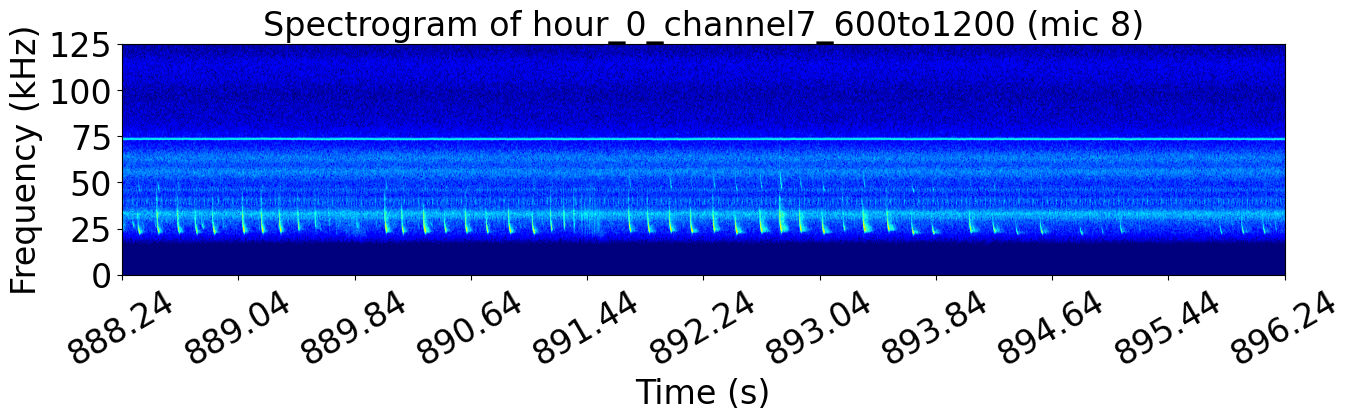

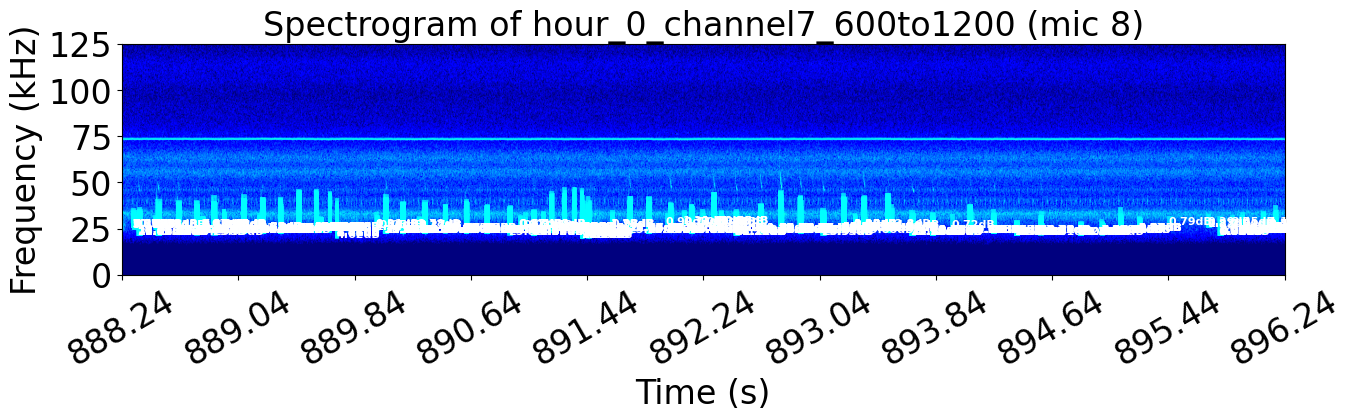

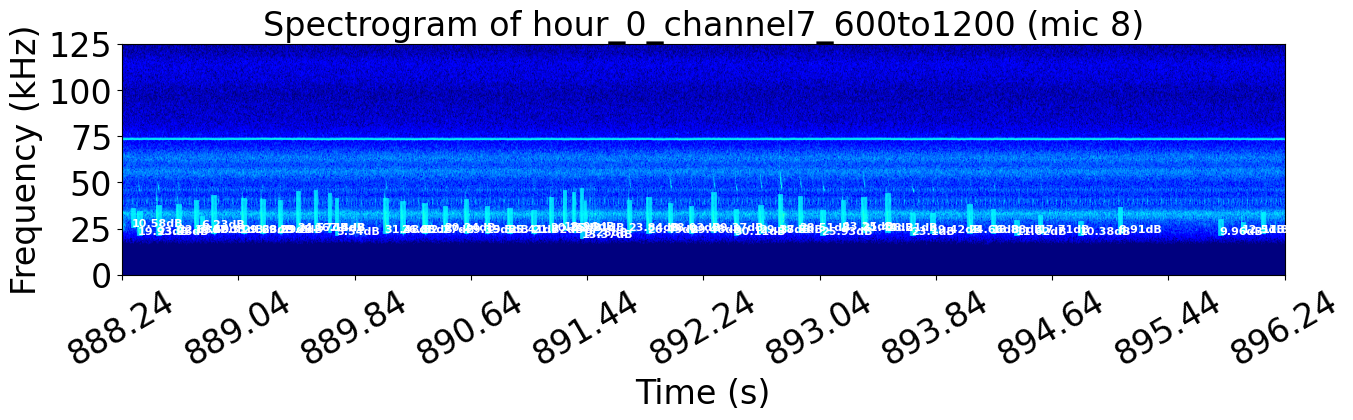

In [287]:
%matplotlib inline

file_offset = 600
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']
removed_overlaps = localize.remove_overlapping_events(channel_dets, OVERLAP_TIME_THRESHOLD=12e-3)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()
tagged_dets = bt.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[6]
start = bout['start_time'] - file_offset + 5
length = 8
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=5].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

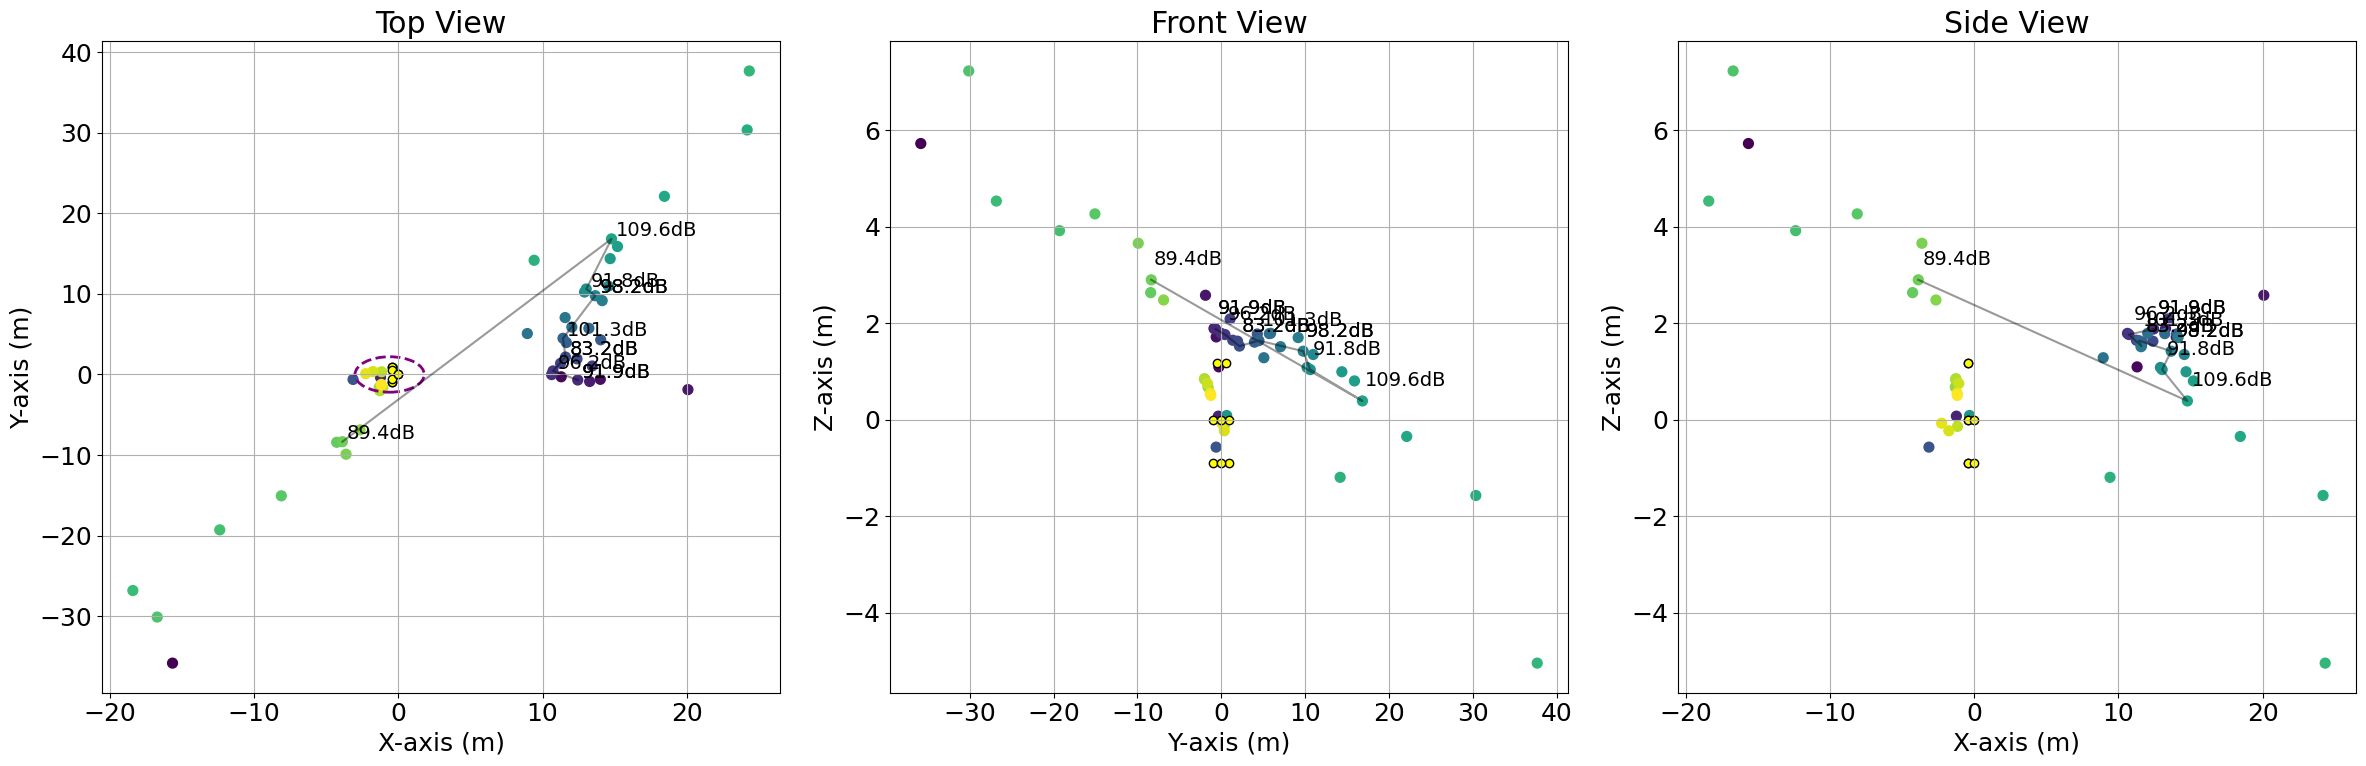

In [290]:
calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

e1 = -0.6
e2 = 0
ellpse_hori_radius = 2.4
ellpse_vert_radius = 2.2
source_x_coords = source_points[0,:]
source_y_coords = source_points[1,:]
distance_of_points_from_ellipse = (((source_x_coords - e1) / ellpse_hori_radius)**2) + (((source_y_coords - e2) / ellpse_vert_radius)**2)
ellipse_based_indices = distance_of_points_from_ellipse>1
dets_outside_ellipse = set_for_tdoa[ellipse_based_indices]
src_points_outside_ellipse = source_points[:,ellipse_based_indices]

dist_travel_per_point = ((src_points_outside_ellipse[:,1:] - src_points_outside_ellipse[:,:-1])**2)[:3,:].sum(axis=0)
time_between_points = (dets_outside_ellipse['end_time'][1:].values - dets_outside_ellipse['start_time'][:-1].values)
speed_between_points = dist_travel_per_point / time_between_points
speed_threshold = 8
speed_based_indices = np.concatenate([[speed_threshold], speed_between_points])<speed_threshold
valid_speed_dets_outside_ellipse = dets_outside_ellipse[speed_based_indices]
valid_speed_src_points_outside_ellipse = src_points_outside_ellipse[:,speed_based_indices]


a = 0.003
wavelength = C / valid_speed_dets_outside_ellipse['peak_frequency_SPECTROGRAM'].values
k = 2*np.pi/wavelength
ka = k*a
theta = np.pi/2

dist_bat_from_ref_mic = np.sqrt(np.sum(valid_speed_src_points_outside_ellipse[:3,:]**2, axis=0))
call_vrms_vals = call_voltage_rms[ellipse_based_indices, ind_of_selected_channel][speed_based_indices]
RL_dB_re_20uPa = convertVtoRL(call_vrms_vals, -38, 12, 200)
### Atmospheric attenuation found usinh Jakobsen at. al 2013
atmos_loss_DB = absorption(valid_speed_dets_outside_ellipse['peak_frequency_SPECTROGRAM'].values)*dist_bat_from_ref_mic
### Geometric Spreading calculated using Jakobsen et. al 2013
spreading_dB = 20*np.log10(dist_bat_from_ref_mic)
D_theta = 2*special.j1(ka*np.sin(theta))/(ka*np.sin(theta))
D_theta_dB = -20*np.log10(np.abs(D_theta))
TL_dB = atmos_loss_DB+spreading_dB+D_theta_dB
bat_SL_dB_re_20uPa = RL_dB_re_20uPa + TL_dB

delta_t = valid_speed_dets_outside_ellipse['start_time'][1:].reset_index(drop=True) - valid_speed_dets_outside_ellipse['end_time'][:-1].reset_index(drop=True)
delta_x = (valid_speed_src_points_outside_ellipse[0,1:] - valid_speed_src_points_outside_ellipse[0,:-1])
delta_y = (valid_speed_src_points_outside_ellipse[1,1:] - valid_speed_src_points_outside_ellipse[1,:-1])
delta_z = (valid_speed_src_points_outside_ellipse[2,1:] - valid_speed_src_points_outside_ellipse[2,:-1])
delta_dist = ((delta_x**2) + (delta_y**2) + (delta_z**2))**0.5

flight_speed_per_2points = (delta_dist/delta_t.values)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':18})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, valid_speed_dets_outside_ellipse, valid_speed_src_points_outside_ellipse, 
                                       source_points, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')
ellipse = patches.Ellipse((e1, e2), width=2*ellpse_hori_radius, height=2*ellpse_vert_radius, edgecolor="purple", facecolor="none", linestyle="--", linewidth=2)
ax1.add_patch(ellipse)
plot_dB_labels_2d(ax1, valid_speed_src_points_outside_ellipse[0,:], valid_speed_src_points_outside_ellipse[1,:], bat_SL_dB_re_20uPa[0])
# ax1.set_xlim(-2, 10)
# ax1.set_ylim(-10, 12)
# ax1.set_xticks(np.arange(-2, 12, 2))
# ax1.set_yticks(np.arange(-12, 14, 2))

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')
plot_dB_labels_2d(ax2, valid_speed_src_points_outside_ellipse[1,:], valid_speed_src_points_outside_ellipse[2,:], bat_SL_dB_re_20uPa[0])
# ax2.set_xlim(-10, 12)
# ax2.set_ylim(-2, 4)
# ax2.set_xticks(np.arange(-12, 14, 2))
# ax2.set_yticks(np.arange(-2, 6, 2))

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')
plot_dB_labels_2d(ax3, valid_speed_src_points_outside_ellipse[0,:], valid_speed_src_points_outside_ellipse[2,:], bat_SL_dB_re_20uPa[0])
# ax3.set_xlim(-2, 10)
# ax3.set_ylim(-2, 4)
# ax3.set_xticks(np.arange(-2, 12, 2))
# ax3.set_yticks(np.arange(-2, 6, 2))

fig.tight_layout()
plt.show()

Animation saved as 20250427__UBNA0424deployment_3d_trajectory_600.mp4


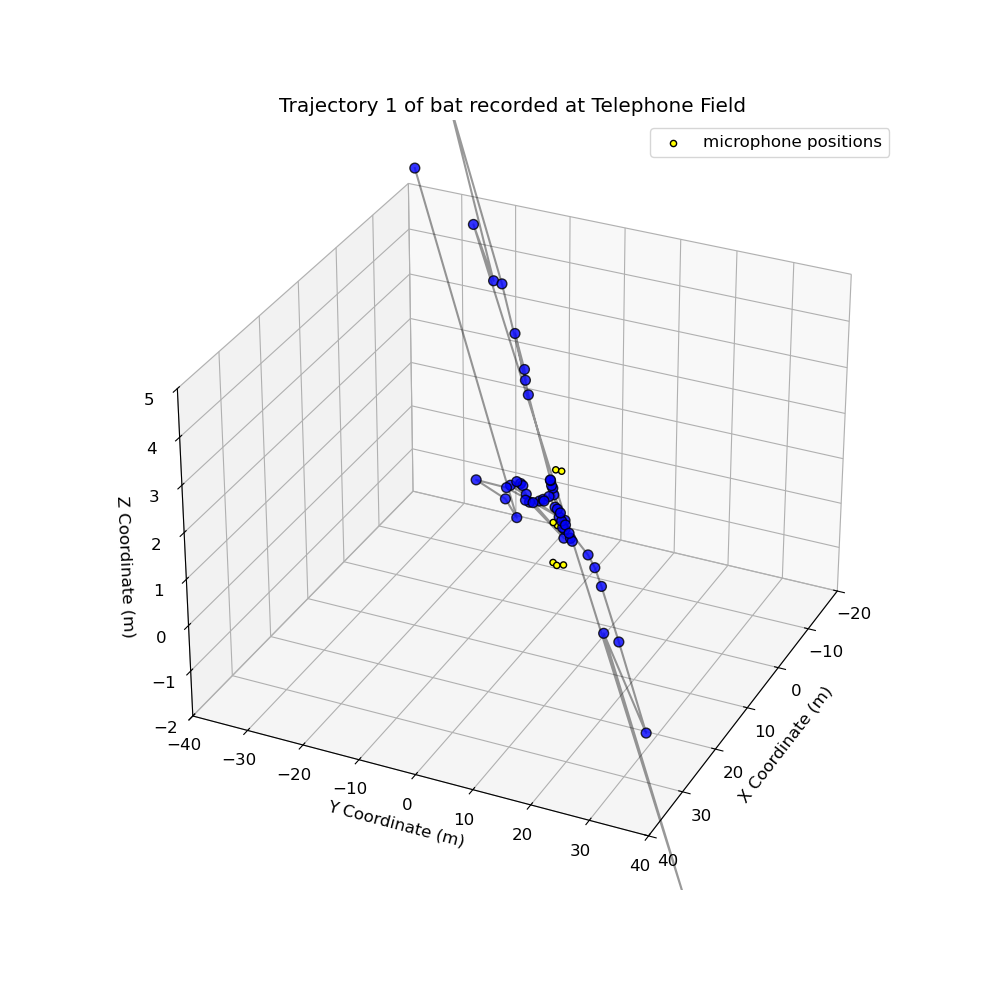

In [294]:
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
ax.cla()

scatter = ax.scatter([], [], [], alpha=1, s=50)
line, = ax.plot([], [], [], color='k', alpha=0.4)

def update(frame):
    ax.cla()  # Clear the axis
    
    # Redraw the scatter points up to the current frame
    ax.scatter(
        source_points[0, :frame],
        source_points[1, :frame],
        source_points[2, :frame],
        facecolor='blue',
        edgecolor='k',
        alpha=0.8,
        s=50,
    )
    
    # Redraw the trajectory line up to the current frame
    ax.plot(
        source_points[0, :frame],
        source_points[1, :frame],
        source_points[2, :frame],
        color='k',
        alpha=0.4,
    )

    ax.scatter(xs=A_locs_mat_tdoa_meters[:, 0], ys=A_locs_mat_tdoa_meters[:, 1], zs=A_locs_mat_tdoa_meters[:, 2], facecolor='yellow', 
               edgecolor='k', alpha=1, label='microphone positions')
    ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)
    
    # Set dynamic camera view
    elev = 30  # Fixed elevation angle
    azim = frame * 0.5  # Rotate azimuth angle by 2 degrees per frame
    ax.view_init(elev, azim)
    
    # Restore axis labels and title after clearing
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_zlabel('Z Coordinate (m)')
    ax.set_title('Trajectory 1 of bat recorded at Telephone Field')
    ax.set_xlim([-20, 40])
    ax.set_ylim([-40, 40])
    ax.set_zlim([-2, 5])

    ax.legend()


num_frames = source_points.shape[1]
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50)

video_filename = f'20250427__UBNA0424deployment_3d_trajectory_{file_offset}.mp4'
ani.save(video_filename, writer='ffmpeg', fps=20)

print(f"Animation saved as {video_filename}")
plt.show()